Available instruments:
('GPIB0::24::INSTR',)
Connected to:
KEITHLEY INSTRUMENTS INC.,MODEL 2400,4115121,C33   Mar 31 2015 09:32:39/A02  /S/V

Starting IV sweep...
V = -0.010 V   I = -1.000085e-05 A
V = -0.005 V   I = -5.206354e-06 A
V = 0.000 V   I = -1.308903e-07 A
V = 0.005 V   I = 5.097123e-06 A
V = 0.010 V   I = 1.000019e-05 A
Data saved to iv_data.csv


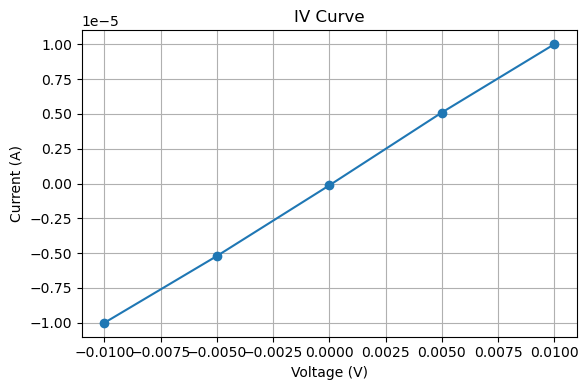

In [1]:
import pyvisa
import numpy as np
import matplotlib.pyplot as plt
import time

# -----------------------------
# USER SETTINGS
# -----------------------------
V_START = -10e-3
V_STOP  = 10e-3
NUM_POINTS = 5

CURRENT_COMPLIANCE = 10e-6   # 10 mA safety limit
DELAY = 0.1                 # seconds between points

VISA_ADDRESS = "GPIB0::24::INSTR"
# Example USB:
# VISA_ADDRESS = "USB0::0x05E6::0x2400::1234567::INSTR"

# -----------------------------
# CONNECT TO INSTRUMENT
# -----------------------------
rm = pyvisa.ResourceManager()

print("Available instruments:")
print(rm.list_resources())

keithley = rm.open_resource(VISA_ADDRESS)

keithley.timeout = 5000

print("Connected to:")
print(keithley.query("*IDN?"))

# -----------------------------
# RESET + CONFIGURE
# -----------------------------
keithley.write("*RST")

# Source voltage
keithley.write(":SOUR:FUNC VOLT")

# Measure current
keithley.write(":SENS:FUNC 'CURR'")

# Set current compliance
keithley.write(f":SENS:CURR:PROT {CURRENT_COMPLIANCE}")

# Use fixed voltage mode
keithley.write(":SOUR:VOLT:MODE FIX")

# Enable output
keithley.write(":OUTP ON")

# -----------------------------
# IV SWEEP
# -----------------------------
voltages = np.linspace(V_START, V_STOP, NUM_POINTS)

measured_currents = []

print("Starting IV sweep...")

for v in voltages:

    # Set source voltage
    keithley.write(f":SOUR:VOLT {v}")

    # Wait for settling
    time.sleep(DELAY)

    # Read measurement
    reading = keithley.query(":READ?")

    # Keithley returns:
    # voltage,current,resistance,time,status
    values = reading.split(',')

    current = float(values[1])

    measured_currents.append(current)

    print(f"V = {v:.3f} V   I = {current:.6e} A")

# -----------------------------
# SHUT DOWN
# -----------------------------
keithley.write(":OUTP OFF")
keithley.close()

# -----------------------------
# SAVE DATA
# -----------------------------
data = np.column_stack((voltages, measured_currents))

np.savetxt(
    "iv_data.csv",
    data,
    delimiter=",",
    header="Voltage(V),Current(A)",
    comments=""
)

print("Data saved to iv_data.csv")

# -----------------------------
# PLOT
# -----------------------------
plt.figure(figsize=(6,4))
plt.plot(voltages, measured_currents, 'o-')
plt.xlabel("Voltage (V)")
plt.ylabel("Current (A)")
plt.title("IV Curve")
plt.grid(True)
plt.tight_layout()
plt.show()

In [2]:
0.01/10e-6

999.9999999999999

In [2]:
# User instructions: import the myHF2LI and magnet objects for the sagnac interferometer





# patch the old packages calling visa
# this is a hack to make the old packages work with pyvisa

#############################################################################################################################
import pyvisa

# Simulate the `visa` module as an alias for `pyvisa`
import sys

# Create a fake 'visa' module, which is essentially an alias for pyvisa
sys.modules['visa'] = pyvisa

# Optionally, map all attributes from pyvisa to visa (this is technically unnecessary because the alias works)
for attr in dir(pyvisa):
    setattr(sys.modules['visa'], attr, getattr(pyvisa, attr))

#############################################################################################################################


# Keithley

In [6]:
import pymeasure

ModuleNotFoundError: No module named 'pymeasure'

In [1]:
import sys
module_dir = r"C:\Users\spint\Documents\GitHub\SagnacOperatingSys\pymeasureMod\pymeasure\instruments"
sys.path.append(module_dir)
from keithley.keithley2400 import Keithley2400 
keith24 = Keithley2400("GPIB::24")

ModuleNotFoundError: No module named 'pymeasure'

In [ ]:
keith1.source_current = 1e-3
keith1.source_current = 0

In [ ]:
# keith1.source_current = 1e-5
# time.sleep(1)
keith1.source_current = 0
keith1.resistance


In [ ]:
keith1.apply_current()
time.sleep(1)
print(f"done")


In [ ]:
keith1.disable_source()

In [ ]:
keith1.voltage[0]

In [ ]:
keith2.voltage[0]

In [ ]:


from pymeasure.instruments.keithley import Keithley2400
keithley = Keithley2400("GPIB::26")

In [ ]:
# keithley.apply_current()# Sets up to source current
# keithley.source_current_range = 10e-3 # Sets the source current range to 10 mA


In [ ]:
keithley.source_current

In [ ]:
keithley.voltage

In [ ]:
keithley.compliance_voltage = 10# Sets the compliance voltage to 10 V
keithley.source_current = 0 # Sets the source current to 0 mA
keithley.enable_source()# Enables the source output

keithley.measure_voltage()# Sets up to measure voltage

# keithley.ramp_to_current(5e-3)# Ramps the current to 5 mA
print(keithley.voltage) 

In [ ]:
# keith1 = Keithley2400("GPIB::26") #currently NI Max is reading as GPIB::26
# print(f"Check that output on Keithley is on")
keith1.enable_source()
keith1.measure_resistance()

# Pure Keithley

In [ ]:
import sys
module_dir = r"C:\Users\luogroup\AppData\Roaming\Python\Python311\site-packages\pymeasure\instruments"
sys.path.append(module_dir)
from keithley.keithley2400 import Keithley2400 


In [ ]:
keith1 = Keithley2400("GPIB::26")

In [ ]:
keith1.source_current = 1e-3
keith1.source_current = 0